# Learning and Adaptation

The Learning and Adaptation pattern enables agents to iteratively improve their outputs through an evaluate → select → mutate → repeat cycle. Inspired by evolutionary algorithms and systems like SICA and OpenEvolve, the agent uses an LLM to generate variants of a program, scores them, keeps the best, and repeats until a fitness threshold is reached or iterations are exhausted.

> **🧭 When to use this pattern — and how Flyte helps**
>
> Use learning and adaptation when agents must operate in dynamic, uncertain, or evolving conditions — improving over time and handling novel situations autonomously. Flyte's sandbox primitives (`flyte.sandbox.create`, `orchestrate_local`, `CodeModeAgent`) run each generated candidate in a fresh, isolated container, so a self-improving agent can execute its own code safely and cache successful evaluations.

## Implementation with Flyte v2 + sandboxing

Evolving LLM-generated code is a great showcase for Flyte's sandboxing. This notebook runs **in-process / Monty** so it works on the local devbox, and documents the container code-sandbox as a Union-cluster option:

- **`CodeModeAgent`** (§8) — the agent writes its own test cases; its generated code runs in a **Monty** sandbox (in-process).
- **`orchestrate_local(...)`** (§9) — the Monty workflow sandbox: an LLM-emitted control-flow string runs with only whitelisted functions (in-process).
- **`flyte.sandbox.create(...)`** — a container code-sandbox for true isolation; **requires a Union cluster** (see *Sandbox options* near the end).

#### OpenEvolve vs Flyte v2 + sandboxing

| Aspect | OpenEvolve | Flyte v2 + sandboxing |
|--------|-----------|------------------------|
| **Evolution loop** | `OpenEvolve(...)` + `await evolve.run(iterations=N)` | Explicit async loop inside `@env.task` |
| **Candidate execution** | Subprocess `evaluator.py` | In-process (Monty) on the devbox; container code-sandbox (`flyte.sandbox.create`) on a Union cluster |
| **Test design** | Fixed `evaluator.py` | `CodeModeAgent` designs tests adaptively |
| **Dynamic control flow** | Library-internal | `orchestrate_local` — Monty workflow sandbox |
| **Observability** | Logs | `flyte.report` live tab + traced helpers in the UI |
| **Secrets** | `os.environ` | `flyte.Secret` injected by cluster |

### 1. Install dependencies

In [ ]:
!uv pip install 'flyte[tui]' litellm anthropic pydantic-monty

### Start the devbox

If you haven't already, install the flyte package with the command above, then launch the local cluster:

In [ ]:
!flyte start devbox

### 2. Store your API key

In [ ]:
!flyte create secret ANTHROPIC_API_KEY --value sk-...

### 3. Import dependencies and configure the TaskEnvironment

In [11]:
import json
import os
from dataclasses import dataclass, field
from datetime import timedelta

from anthropic import AsyncAnthropic
import flyte
import flyte.report
from flyte.sandbox import sandbox_environment

flyte.init_from_config()

_image = (
    flyte.Image.from_debian_base(name="evo-agent", python_version=(3, 12))
    .with_pip_packages("anthropic>=0.25.0")
)

# evolve_program orchestrates a sandbox, so it depends on the sandbox environment.
evo_env = flyte.TaskEnvironment(
    name="evo_agent",
    image=_image,
    resources=flyte.Resources(cpu="1", memory="2Gi"),
    secrets=[
        flyte.Secret(key="ANTHROPIC_API_KEY", as_env_var="ANTHROPIC_API_KEY"),
    ],
    depends_on=[sandbox_environment],
)

### 4. Define data models

OpenEvolve stores candidate programs as files and tracks metrics in a `Program` database. In Flyte v2, typed dataclasses replace file-based state — every generation is a serializable `ProgramVariant` that is visible as structured output in the UI.

In [12]:
@dataclass
class ProgramVariant:
    """A single candidate program and its evaluation score."""
    code: str = ""
    score: float = 0.0
    generation: int = 0
    mutation_notes: str = ""


@dataclass
class EvoResult:
    """Final output of the evolutionary coding agent."""
    task_description: str = ""
    best_code: str = ""
    best_score: float = 0.0
    generations: int = 0
    total_variants_tried: int = 0
    converged: bool = False


## In-process evaluation

`_evaluate` runs each candidate **in-process** inside `evolve_program`, so the whole evolutionary loop runs end-to-end on the local devbox. The responsibilities:

| Step | Uses LLM? | Runs where |
|------|-----------|------------|
| `_mutate` | Yes (`AsyncAnthropic`) | task process (open-ended: LLM decides *how* to improve) |
| `_evaluate` | No | task process (deterministic test run) |
| `_critique` | Yes (`AsyncAnthropic`) | task process (open-ended improvement direction) |

> **Why in-process here?** It keeps the loop dependency-free so it runs end-to-end on the devbox. §8 adds adaptive, agent-designed tests (still evaluated in-process via the Monty sandbox), and the *Sandbox options (Union cluster)* section near the end shows the container-isolated `flyte.sandbox.create` path.

In [13]:
MUTATION_SYSTEM = """\
You are an expert Python programmer. Given a function and feedback, produce an improved version.

Rules:
- Return ONLY the complete improved Python function, no explanation.
- Keep the same function signature.
- Make exactly one focused improvement per mutation.
- The function must be self-contained (no imports outside the function body)."""


@flyte.trace
async def _mutate(
    current_code: str,
    task_description: str,
    critique: str,
) -> ProgramVariant:
    """Ask the LLM to produce an improved variant. Replaces OpenEvolve's LLM sampler."""
    client = AsyncAnthropic()
    response = await client.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=1024,
        system=MUTATION_SYSTEM,
        messages=[{
            "role": "user",
            "content": (
                f"Task: {task_description}\n\n"
                f"Current code:\n```python\n{current_code}\n```\n\n"
                f"Critique / improvement direction: {critique}\n\n"
                "Produce the improved function:"
            ),
        }],
    )
    raw = response.content[0].text.strip()
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()
    return ProgramVariant(code=raw, mutation_notes=critique)


@flyte.trace
async def _evaluate(
    variant: ProgramVariant,
    test_cases: list[tuple],
    fn_name: str,
) -> ProgramVariant:
    """Score a variant by running it against the test cases, in-process.

    Runs inside this task's container — fine on the local devbox. For true isolation of
    untrusted code, score each candidate in its own container via `flyte.sandbox.create`
    (see the "Sandbox options (Union cluster)" section near the end).
    """
    score = 0.0
    error_msg = ""
    namespace: dict = {}
    try:
        exec(compile(variant.code, "<variant>", "exec"), namespace)
        fn = namespace.get(fn_name)
        if not callable(fn):
            error_msg = "function not found after exec"
        else:
            passed = 0
            errs: list[str] = []
            for inp, exp in test_cases:
                try:
                    inputs = list(inp) if isinstance(inp, (tuple, list)) else [inp]
                    out = fn(*inputs)
                    if out == exp:
                        passed += 1
                except Exception as exc:
                    errs.append(str(exc))
            score = passed / len(test_cases) if test_cases else 0.0
            error_msg = "; ".join(errs[:3]) if errs else f"{passed}/{len(test_cases)} tests passed"
    except Exception as e:
        error_msg = f"compile error: {e}"

    return ProgramVariant(
        code=variant.code,
        score=score,
        generation=variant.generation,
        mutation_notes=error_msg or variant.mutation_notes,
    )


@flyte.trace
async def _critique(
    variant: ProgramVariant,
    task_description: str,
    test_cases: list[tuple],
    fn_name: str,
) -> str:
    """Ask the LLM to critique the current best program and suggest a mutation direction."""
    client = AsyncAnthropic()
    failed = [
        f"  {inp} → expected {exp}"
        for inp, exp in test_cases
    ]
    response = await client.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=256,
        system="You are a code reviewer. Suggest ONE specific improvement for a Python function.",
        messages=[{
            "role": "user",
            "content": (
                f"Task: {task_description}\n"
                f"Current score: {variant.score:.2f}\n"
                f"Code:\n```python\n{variant.code}\n```\n"
                f"Test cases (input → expected):\n" + "\n".join(failed) + "\n\n"
                "In one sentence, what should the next mutation focus on?"
            ),
        }],
    )
    return response.content[0].text.strip()

### 6. Define the evolutionary coding agent task

OpenEvolve's `await evolve.run(iterations=1000)` hides a generate → evaluate → select loop inside the library. In Flyte v2, this loop is explicit Python — the same logic, fully transparent:

1. **Mutate** the current best program with LLM guidance
2. **Evaluate** the variant against test cases
3. **Select** the better of old vs. new (elitist selection)
4. Update the live report and repeat

`@flyte.trace` on each helper means the task resumes from the last checkpoint on pod failure.

In [14]:
def _html_escape(text: str) -> str:
    return text.replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")


@evo_env.task(
    retries=2,
    timeout=timedelta(minutes=15),
    cache=flyte.Cache(behavior="disable"),
    report=True,
)
async def evolve_program(
    task_description: str,
    initial_code: str,
    test_cases: list[list],   # list of [inputs, expected]; inputs is list for multi-arg
    fn_name: str,
    max_generations: int = 10,
    target_score: float = 1.0,
) -> EvoResult:
    """
    Evolutionary coding agent: iteratively improve a Python function.

    Replaces OpenEvolve's:
      evolve = OpenEvolve(initial_program_path, evaluation_file, config_path)
      best_program = await evolve.run(iterations=1000)

    The generate → evaluate → select loop is the same logic, now explicit.
    """
    # Convert nested lists to tuples for test_cases
    tc: list[tuple] = [(tuple(inp) if isinstance(inp, list) else inp, exp)
                       for inp, exp in test_cases]

    best = await _evaluate(
        ProgramVariant(code=initial_code, generation=0),
        tc, fn_name,
    )
    total_tried = 1
    report_rows: list[str] = []

    for gen in range(1, max_generations + 1):
        # Critique current best → get mutation direction
        critique = await _critique(best, task_description, tc, fn_name)

        # Generate a mutant
        mutant = await _mutate(best.code, task_description, critique)
        mutant = ProgramVariant(
            code=mutant.code,
            generation=gen,
            mutation_notes=mutant.mutation_notes,
        )

        # Evaluate the mutant
        mutant = await _evaluate(mutant, tc, fn_name)
        total_tried += 1

        # Elitist selection: keep the better program
        improved = mutant.score > best.score
        if improved:
            best = mutant

        color = "green" if improved else "gray"
        report_rows.append(
            f"<tr><td>{gen}</td>"
            f"<td style='color:{color}'>{mutant.score:.2f}</td>"
            f"<td>{best.score:.2f}</td>"
            f"<td>{_html_escape(critique[:80])}...</td></tr>"
        )

        await flyte.report.replace.aio(
            "<!DOCTYPE html><html><body>"
            f"<h2>Evolving: {_html_escape(task_description[:60])}</h2>"
            f"<p>Generation {gen} / {max_generations} | Best score: <strong>{best.score:.2f}</strong></p>"
            "<table border='1' cellpadding='4'>"
            "<tr><th>Gen</th><th>Mutant</th><th>Best</th><th>Critique</th></tr>"
            + "".join(report_rows)
            + "</table>"
            f"<h3>Current best code</h3><pre>{_html_escape(best.code)}</pre>"
            "</body></html>"
        )
        await flyte.report.flush.aio()

        if best.score >= target_score:
            break

    return EvoResult(
        task_description=task_description,
        best_code=best.code,
        best_score=best.score,
        generations=gen,
        total_variants_tried=total_tried,
        converged=best.score >= target_score,
    )

### 7. Run locally

In [9]:
# Start with a broken implementation — the agent must fix it
INITIAL_CODE = """
def is_palindrome(s: str) -> bool:
    # placeholder — always returns False
    return False
""".strip()

TEST_CASES = [
    [["racecar"], True],
    [["hello"], False],
    [["level"], True],
    [["world"], False],
    [["madam"], True],
]

run = await flyte.run.aio(
    evolve_program,
    task_description="A function is_palindrome(s) that returns True if s reads the same forwards and backwards.",
    initial_code=INITIAL_CODE,
    test_cases=TEST_CASES,
    fn_name="is_palindrome",
    max_generations=8,
    target_score=1.0,
)
await run.wait.aio()
result: EvoResult = run.outputs()[0]

print(f"Converged: {result.converged}")
print(f"Best score: {result.best_score:.2f} after {result.generations} generations ({result.total_variants_tried} variants)")
print(f"\nBest code:\n{result.best_code}")

> Building 2 images...

> Building image evo-agent for environment evo_agent

> Building image flyte for environment sandbox-runtime

i Image ghcr.io/flyteorg/flyte:py3.12 already exists, skipping build

✓ Built image for environment evo_agent: localhost:30000/evo-agent:604924cfea83e0c91cf26689e267fd6c

✓ Built image for environment sandbox-runtime: ghcr.io/flyteorg/flyte:py3.12

06:01:52.100120 WARNING   _type_engine.py:2012 - Unsupported Type <class 'list'> found, Flyte will default to use PickleFile as the transport. Pickle can only  
                         be used to send objects between the exact same version of Python, and we strongly recommend to use python type that flyte support.

Output()

Converged: True
Best score: 1.00 after 1 generations (2 variants)

Best code:
def is_palindrome(s: str) -> bool:
    return s == s[::-1]


### 8. Adaptive evaluation with CodeModeAgent

The fixed test suite in §5–7 is only as good as the tests you wrote. `CodeModeAgent` removes that limit: instead of a hardcoded suite, the agent receives the task description and the candidate code, **designs its own test cases** (typical inputs, edge cases, boundary values), and calls `run_tests_tool` to execute them.

| | Fixed test suite (§5–7) | Adaptive evaluation (this section) |
|--|--|--|
| **Test cases** | hardcoded, passed in | agent generates from the task description |
| **Task signature** | needs `test_cases` + `fn_name` | only `task_description` + `fn_name` |
| **Edge cases** | limited to what you wrote | agent infers from the spec |

#### `run_tests_tool`: a plain `async def`

`CodeModeAgent` has the LLM emit a Python snippet that the **Monty sandbox** runs, calling its tools from inside. A plain `async def` tool runs **in-process** in that sandbox — so `run_tests_tool` scores the candidate without spawning a separate Flyte action. (Pass an `@env.task` as the tool instead and the bridge schedules it as its own action — durable, but that nested-action path needs a Union cluster.)

> **Model note:** the model must emit *plain Python* (not chat prose or tool-call XML), so we use `claude-sonnet-4-6` with a directive prompt whose last line pins the return value. Smaller models tend to emit prose/XML the Monty sandbox can't compile.

In [15]:
from flyte.ai.agents import CodeModeAgent

_image_adaptive = (
    flyte.Image.from_debian_base(name="evo-agent-adaptive", python_version=(3, 12))
    .with_pip_packages("anthropic>=0.25.0", "litellm", "pydantic-monty")
)

evo_env_adaptive = flyte.TaskEnvironment(
    name="evo_agent_adaptive",
    image=_image_adaptive,
    resources=flyte.Resources(cpu="1", memory="2Gi"),
    secrets=[
        flyte.Secret(key="ANTHROPIC_API_KEY", as_env_var="ANTHROPIC_API_KEY"),
    ],
    depends_on=[sandbox_environment],
)


# run_tests_tool is a plain `async def` (not an @env.task), so CodeModeAgent's bridge
# calls it directly as a trace-ref inside the Monty runtime. It evaluates the candidate
# IN-PROCESS for devbox reliability. For container isolation, see the Union-cluster
# sandbox option below (running this nested would need a full cluster).
async def run_tests_tool(code: str, fn_name: str, test_cases_json: str) -> str:
    """Run candidate `code` against `test_cases_json`; return JSON {score, passed, total, error_msg}.

    test_cases_json format: [{"inputs": [arg1, ...], "expected": <value>}, ...]
    Use JSON booleans (true/false), not Python booleans.
    """
    import json as _j
    score, error_msg, passed, total = 0.0, "", 0, 0
    ns: dict = {}
    try:
        exec(compile(code, "<candidate>", "exec"), ns)
        fn = ns.get(fn_name)
        if not callable(fn):
            error_msg = "function not found"
        else:
            cases = _j.loads(test_cases_json)
            total = len(cases)
            for item in cases:
                try:
                    if fn(*item["inputs"]) == item["expected"]:
                        passed += 1
                except Exception as exc:
                    if not error_msg:
                        error_msg = str(exc)
            score = passed / total if total else 0.0
    except Exception as exc:
        error_msg = str(exc)
    return _j.dumps({"score": score, "error_msg": error_msg, "passed": passed, "total": total})


# CodeModeAgent emits a Python *snippet* that the Monty sandbox executes — so the model
# must write plain Python, not prose or tool-call XML. We use claude-sonnet-4-6 (haiku tends
# to emit chat/XML here) and a directive prompt whose last instruction pins the return value.
eval_agent_adaptive = CodeModeAgent(
    tools=[run_tests_tool],
    model="claude-sonnet-4-6",
    max_retries=2,
    system_prompt_prefix=(
        "You are an adaptive code evaluator. Emit a SINGLE Python script — no prose, no XML, "
        "no markdown fences. In it:\n"
        "1. Build a JSON string `tests` = a JSON array of {\"inputs\": [...], \"expected\": <value>} "
        "objects (use JSON booleans true/false) covering typical inputs, edge cases, and boundary "
        "values for the function.\n"
        "2. Call run_tests_tool(code, fn_name, tests).\n"
        "3. The LAST expression in your script must be that run_tests_tool(...) call, so its raw "
        "string result becomes the return value."
    ),
)


@flyte.trace
async def _evaluate_adaptive(
    variant: ProgramVariant,
    task_description: str,
    fn_name: str,
) -> ProgramVariant:
    """Score a variant: CodeModeAgent designs the test cases; run_tests_tool runs them in-process."""
    agent_result = await eval_agent_adaptive.run.aio(
        message=(
            f"Task: {task_description}\n\n"
            f"Function name: {fn_name}\n\n"
            f"Candidate code:\n```python\n{variant.code}\n```\n\n"
            "Design comprehensive test cases and call run_tests_tool to evaluate this function."
        ),
        history=[],
    )
    try:
        parsed = json.loads(agent_result.summary or "{}")
        score = float(parsed.get("score", 0.0))
        passed = parsed.get("passed", "?")
        total = parsed.get("total", "?")
        error_msg = parsed.get("error_msg", "")
        rationale = f"{passed}/{total} tests passed" + (f" — {error_msg}" if error_msg else "")
    except (json.JSONDecodeError, ValueError):
        score = 0.0
        rationale = agent_result.error or agent_result.summary or "evaluation failed"
    return ProgramVariant(
        code=variant.code,
        score=score,
        generation=variant.generation,
        mutation_notes=rationale,
    )


@flyte.trace
async def _critique_adaptive(variant: ProgramVariant, task_description: str) -> str:
    """Critique using the evaluation feedback stored in mutation_notes."""
    client = AsyncAnthropic()
    response = await client.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=256,
        system="You are a code reviewer. Suggest ONE specific improvement for a Python function.",
        messages=[{
            "role": "user",
            "content": (
                f"Task: {task_description}\n"
                f"Current score: {variant.score:.2f}\n"
                f"Code:\n```python\n{variant.code}\n```\n"
                f"Test feedback: {variant.mutation_notes}\n\n"
                "In one sentence, what should the next mutation focus on?"
            ),
        }],
    )
    return response.content[0].text.strip()

Define the coding agent with adaptive evaluation:

In [16]:
@evo_env_adaptive.task(
    retries=2,
    timeout=timedelta(minutes=20),
    cache=flyte.Cache(behavior="disable"),
    report=True,
)
async def evolve_program_adaptive(
    task_description: str,
    initial_code: str,
    fn_name: str,
    max_generations: int = 10,
    target_score: float = 1.0,
) -> EvoResult:
    """
    Evolutionary coding agent with adaptive evaluation.

    Unlike evolve_program, there are no hardcoded test cases — CodeModeAgent
    designs the test suite each generation based on the task description alone.
    The critique step also uses the agent's evaluation feedback rather than
    failing test cases, making mutation guidance richer and more targeted.
    """
    best = await _evaluate_adaptive(
        ProgramVariant(code=initial_code, generation=0),
        task_description,
        fn_name,
    )
    total_tried = 1
    report_rows: list[str] = []

    for gen in range(1, max_generations + 1):
        critique = await _critique_adaptive(best, task_description)
        mutant = await _mutate(best.code, task_description, critique)
        mutant = ProgramVariant(code=mutant.code, generation=gen, mutation_notes=mutant.mutation_notes)
        mutant = await _evaluate_adaptive(mutant, task_description, fn_name)
        total_tried += 1

        improved = mutant.score > best.score
        if improved:
            best = mutant

        color = "green" if improved else "gray"
        report_rows.append(
            f"<tr><td>{gen}</td>"
            f"<td style='color:{color}'>{mutant.score:.2f}</td>"
            f"<td>{best.score:.2f}</td>"
            f"<td>{_html_escape(critique[:80])}...</td>"
            f"<td>{_html_escape(best.mutation_notes[:60])}</td></tr>"
        )

        await flyte.report.replace.aio(
            "<!DOCTYPE html><html><body>"
            f"<h2>Adaptive: {_html_escape(task_description[:60])}</h2>"
            f"<p>Generation {gen} / {max_generations} | Best score: <strong>{best.score:.2f}</strong></p>"
            "<table border='1' cellpadding='4'>"
            "<tr><th>Gen</th><th>Mutant</th><th>Best</th><th>Critique</th><th>Test feedback</th></tr>"
            + "".join(report_rows)
            + "</table>"
            f"<h3>Current best code</h3><pre>{_html_escape(best.code)}</pre>"
            "</body></html>"
        )
        await flyte.report.flush.aio()

        if best.score >= target_score:
            break

    return EvoResult(
        task_description=task_description,
        best_code=best.code,
        best_score=best.score,
        generations=gen,
        total_variants_tried=total_tried,
        converged=best.score >= target_score,
    )

Run it on the devbox:

In [30]:
run = await flyte.run.aio(
    evolve_program_adaptive,
    task_description=(
        "A function count_vowels(s: str) -> int that returns the number of vowels "
        "(a, e, i, o, u) in s, case-insensitive."
    ),
    initial_code="def count_vowels(s: str) -> int:\n    return 0  # placeholder",
    fn_name="count_vowels",
    max_generations=8,
    target_score=1.0,
)
await run.wait.aio()
result: EvoResult = run.outputs()[0]
print(f"Converged: {result.converged}")
print(f"Best score: {result.best_score:.2f} after {result.generations} generations ({result.total_variants_tried} variants)")
print(f"\nBest code:\n{result.best_code}")

> Building 2 images...

> Building image evo-agent-adaptive for environment evo_agent_adaptive

> Building image flyte for environment sandbox-runtime

✓ Built image for environment evo_agent_adaptive: 
localhost:30000/evo-agent-adaptive:bddd3567eea4d90efa7aaf04beb48824

✓ Built image for environment sandbox-runtime: ghcr.io/flyteorg/flyte:py3.12

Output()

Converged: True
Best score: 1.00 after 1 generations (2 variants)

Best code:
def count_vowels(s: str) -> int:
    return sum(1 for c in s.lower() if c in 'aeiou')


### Sandbox options for isolated execution (Union cluster)

The loops above evaluate candidates **in-process** — fine for the devbox, but it runs untrusted, LLM-generated code in the orchestrator's own process. For true isolation, score each candidate in its own ephemeral container with `flyte.sandbox.create`. A sandbox runs as a **sub-action of a task**, so this path needs a full **Union cluster**: on the local devbox the sub-action can't upload its spec (`spec.pb upload: All connection attempts failed`).

The cells below are a **complete, runnable** version for a Union cluster. The structure mirrors §5–7 exactly — only the evaluation step changes from in-process `_evaluate` to sandboxed `_evaluate_sandboxed`:

1. define the container sandbox once,
2. wrap it in a helper,
3. drop it into the same generate → evaluate → select loop.

In [17]:
# 1) Define the container code-sandbox ONCE. Each call runs `code` against `test_cases_json`
#    in a fresh, isolated container; `auto_io` injects the inputs as locals and collects the
#    named outputs. (This is real Python in a container — NOT the Monty dialect, so normal
#    statements like `passed += 1` are fine here.)
_SANDBOX_EVAL_CODE = """
import json as _j

score, error_msg, passed, total = 0.0, "", 0, 0
namespace = {}
try:
    exec(compile(code, "<candidate>", "exec"), namespace)
    fn = namespace.get(fn_name)
    if fn is None or not callable(fn):
        error_msg = "function not found"
    else:
        test_data = _j.loads(test_cases_json)
        total = len(test_data)
        for item in test_data:
            try:
                if fn(*item["inputs"]) == item["expected"]:
                    passed += 1
            except Exception as exc:
                if not error_msg:
                    error_msg = str(exc)
        score = passed / total if total > 0 else 0.0
except Exception as exc:
    error_msg = str(exc)
"""

eval_sandbox = flyte.sandbox.create(
    name="code-evaluator",
    code=_SANDBOX_EVAL_CODE,
    inputs={"code": str, "fn_name": str, "test_cases_json": str},
    outputs={"score": float, "error_msg": str, "passed": int, "total": int},
    cache="disable",
)

In [18]:
# 2) Helper: score a candidate in an isolated container (sandbox sub-action).
#    NOTE: do NOT decorate this with @flyte.trace. The sandbox runs as a Flyte
#    *sub-action*, and @flyte.trace tries to checkpoint that sub-action's outputs —
#    which conflicts with how sandbox outputs are stored and fails on a real cluster
#    with `IsADirectoryError: /home/flyte`. Plain async is correct here; the sandbox
#    still appears as its own nested action in the UI.
async def _evaluate_sandboxed(
    variant: ProgramVariant,
    test_cases: list[tuple],
    fn_name: str,
) -> ProgramVariant:
    """Score a variant via flyte.sandbox.create — each candidate runs in its own container."""
    test_cases_json = json.dumps([
        {"inputs": list(inp) if isinstance(inp, (tuple, list)) else [inp], "expected": exp}
        for inp, exp in test_cases
    ])
    score, error_msg, passed, total = await eval_sandbox.run.aio(
        code=variant.code, fn_name=fn_name, test_cases_json=test_cases_json,
    )
    return ProgramVariant(
        code=variant.code,
        score=float(score),
        generation=variant.generation,
        mutation_notes=error_msg or f"{passed}/{total} tests passed",
    )


# 3) Same loop as evolve_program (§5-7) — only the evaluation step is sandboxed.
@evo_env.task(
    retries=2,
    timeout=timedelta(minutes=15),
    cache=flyte.Cache(behavior="disable"),
    report=True,
)
async def evolve_program_sandboxed(
    task_description: str,
    initial_code: str,
    test_cases: list[list],
    fn_name: str,
    max_generations: int = 10,
    target_score: float = 1.0,
) -> EvoResult:
    """Evolutionary loop where each candidate is scored in its OWN ephemeral container.
    Requires a Union cluster (the sandbox sub-action does not run on the local devbox)."""
    tc: list[tuple] = [(tuple(inp) if isinstance(inp, list) else inp, exp)
                       for inp, exp in test_cases]

    best = await _evaluate_sandboxed(ProgramVariant(code=initial_code, generation=0), tc, fn_name)
    total_tried = 1

    for gen in range(1, max_generations + 1):
        critique = await _critique(best, task_description, tc, fn_name)
        mutant = await _mutate(best.code, task_description, critique)
        mutant = ProgramVariant(code=mutant.code, generation=gen, mutation_notes=mutant.mutation_notes)
        mutant = await _evaluate_sandboxed(mutant, tc, fn_name)   # <-- sandboxed evaluation
        total_tried += 1

        if mutant.score > best.score:
            best = mutant
        if best.score >= target_score:
            break

    return EvoResult(
        task_description=task_description,
        best_code=best.code,
        best_score=best.score,
        generations=gen,
        total_variants_tried=total_tried,
        converged=best.score >= target_score,
    )

In [19]:
# 4) Run it. NOTE: requires a Union cluster — on the local devbox the sandbox sub-action
#    can't upload its spec (`spec.pb upload: All connection attempts failed`).
run = await flyte.run.aio(
    evolve_program_sandboxed,
    task_description="A function is_palindrome(s) that returns True if s reads the same forwards and backwards.",
    initial_code="def is_palindrome(s: str) -> bool:\n    return False",
    test_cases=[
        [["racecar"], True],
        [["hello"], False],
        [["level"], True],
        [["world"], False],
    ],
    fn_name="is_palindrome",
    max_generations=8,
    target_score=1.0,
)
await run.wait.aio()
result: EvoResult = run.outputs()[0]
print(f"Converged: {result.converged}")
print(f"Best score: {result.best_score:.2f} after {result.generations} generations ({result.total_variants_tried} variants)")
print(f"\nBest code:\n{result.best_code}")

> Building 2 images...

> Building image evo-agent for environment evo_agent

> Building image flyte for environment sandbox-runtime

✓ Built image for environment evo_agent: 
356633062068.dkr.ecr.us-east-2.amazonaws.com/union/demo:evo-agent-604924cfea83e0c91cf26689e267fd6c

✓ Built image for environment sandbox-runtime: 
356633062068.dkr.ecr.us-east-2.amazonaws.com/union/demo:flyte-py3.12

Output()

Run 'upwlv6wzsqktcdf8clj8' completed successfully.

Converged: True
Best score: 1.00 after 1 generations (2 variants)

Best code:
def is_palindrome(s: str) -> bool:
    return s == s[::-1]


The execution on the Union cluster shows that each iteration of the `code-evaluator` agent runs on an isolated container where the Python script is executed but the outputs are captured and passed to the next iteration:

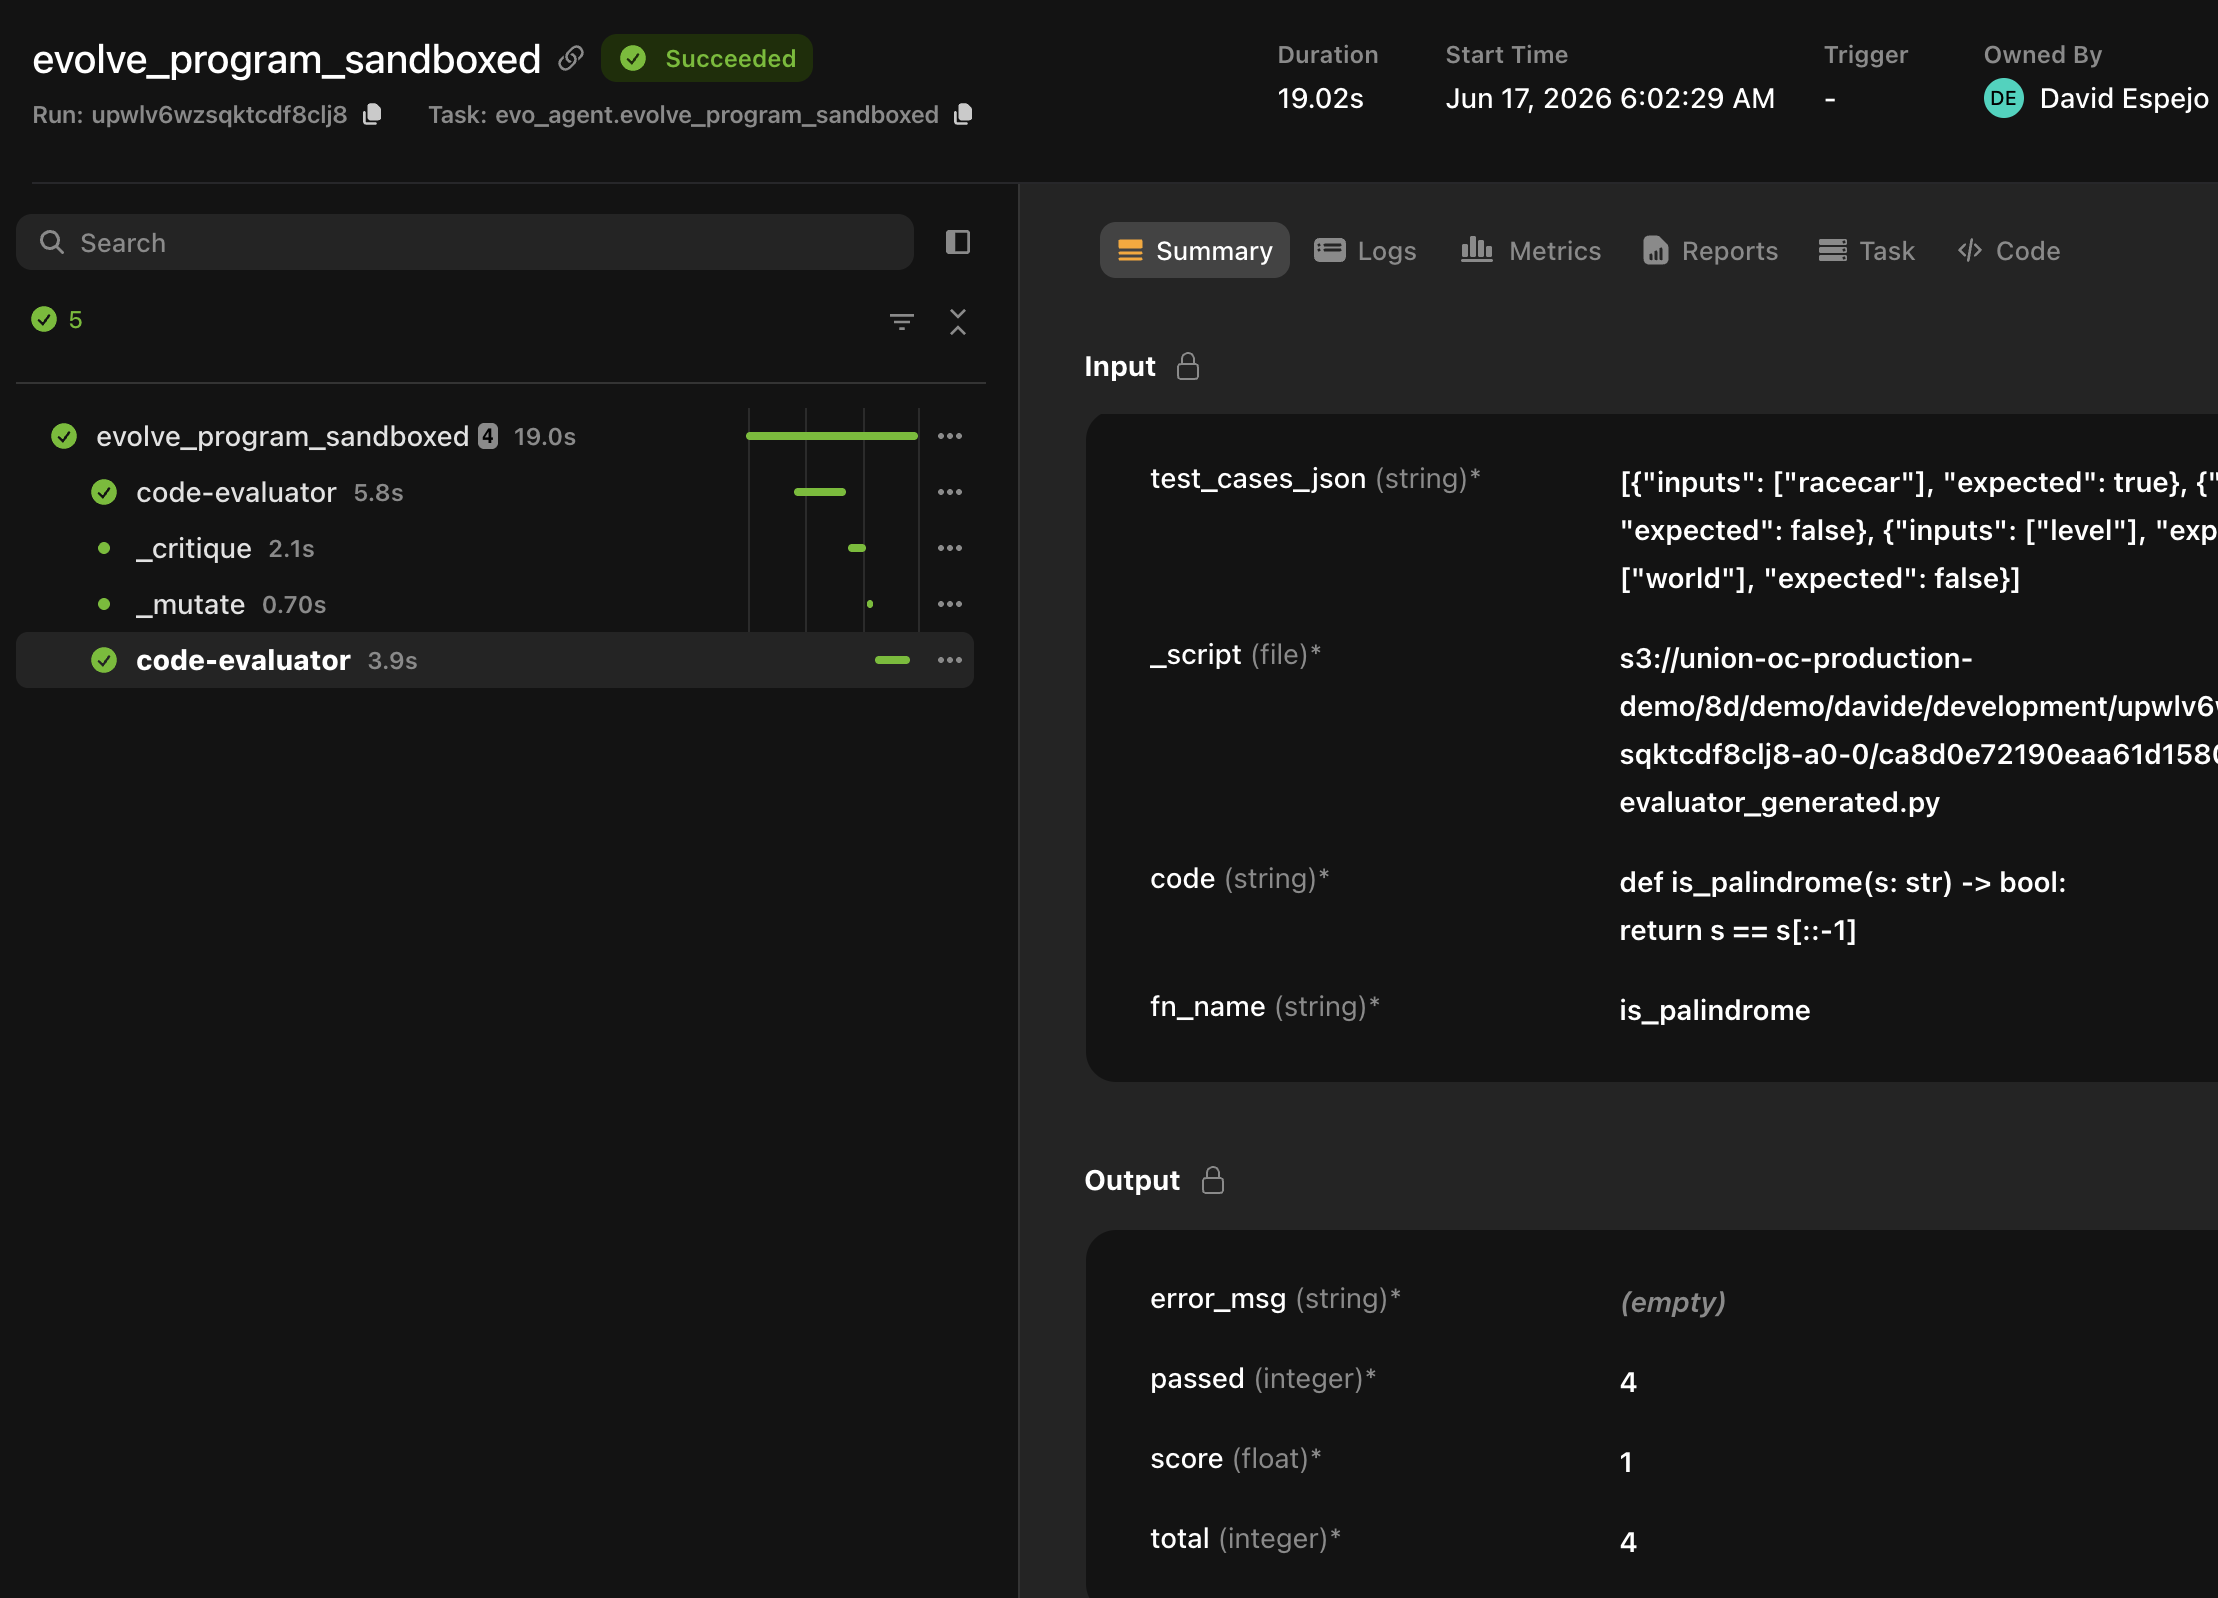